# 04. Trenowanie Modeli — MLP i GNN

> Poprzedni notebook: [03_feature_engineering.ipynb](03_feature_engineering.ipynb)

## Cel:
Wytrenowanie i ewaluacja dwóch modeli do przewidywania **pIC50** na podstawie struktury chemicznej:

- **MLP**
- **GNN**

## Plan działania:
1. **Konfiguracja i wczytanie danych** z notebook 03
2. **Model MLP** — architektura, trening, walidacja
3. **Model GNN** — architektura GIN, trening, walidacja
4. **Ewaluacja i porównanie** — RMSE, MAE, R² na zbiorze testowym
5. **Wizualizacja** — krzywe uczenia, wykresy predicted vs actual
6. **Zapis modeli** i przykład inferencji (SMILES → pIC50)

---

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from torch_geometric.data import Data
from torch_geometric.nn import GINEConv, AttentiveFP, global_mean_pool, global_max_pool
from torch_geometric.loader import DataLoader as GeoDataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
matplotlib.style.use('seaborn-v0_8-darkgrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Biblioteki załadowane pomyślnie.")
print(f"Urządzenie: {DEVICE}")


Biblioteki załadowane pomyślnie.
Urządzenie: cuda


## 1. Konfiguracja i Wczytanie Danych

In [ ]:
BASE_DIR     = Path(r'<ŚCIEŻKA_DO_FOLDERU>') 
FEATURES_DIR = BASE_DIR / "data" / "features"
MODELS_DIR   = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Hiperparametry MLP ────────────────────────────────────────────────────────
MLP_HIDDEN       = [2048, 1024, 512, 256] 
MLP_DROPOUT      = 0.2
MLP_WEIGHT_DECAY = 1e-4
MLP_LR           = 1e-3
MLP_EPOCHS       = 150 
MLP_BATCH        = 2048
MLP_PATIENCE     = 20 

# ── Hiperparametry GNN ─────────────────────────────────────────
GNN_HIDDEN     = 256
GNN_LAYERS     = 4
GNN_TIMESTEPS  = 4
GNN_DROPOUT    = 0.2
GNN_LR         = 5e-4
GNN_EPOCHS     = 250
GNN_BATCH      = 512
GNN_PATIENCE   = 25
GNN_GRAD_CLIP  = 1.0

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Katalog modeli: {MODELS_DIR}")
print(f"\nMLP: hidden={MLP_HIDDEN}, dropout={MLP_DROPOUT}, weight_decay={MLP_WEIGHT_DECAY}, lr={MLP_LR}")
print(f"GNN: hidden={GNN_HIDDEN}, layers={GNN_LAYERS}, timesteps={GNN_TIMESTEPS}, epochs={GNN_EPOCHS}")
print(f"AMP (mixed precision): {'enabled' if DEVICE.type == 'cuda' else 'disabled (CPU)'}")


Katalog modeli: C:\Users\LUMA\Documents\Projects\Personal\Chembl\models

MLP: hidden=[2048, 1024, 512, 256], dropout=0.2, weight_decay=0.0001, lr=0.001
GNN: hidden=256, layers=4, timesteps=4, epochs=250
AMP (mixed precision): enabled


In [3]:
# Wczytanie cech MLP
X_train = np.load(FEATURES_DIR / "mlp_X_train.npy")
X_val   = np.load(FEATURES_DIR / "mlp_X_val.npy")
X_test  = np.load(FEATURES_DIR / "mlp_X_test.npy")
y_train = np.load(FEATURES_DIR / "mlp_y_train.npy")
y_val   = np.load(FEATURES_DIR / "mlp_y_val.npy")
y_test  = np.load(FEATURES_DIR / "mlp_y_test.npy")

print("Dane MLP:")
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}  y_test:  {y_test.shape}")

N_FEATURES = X_train.shape[1]
print(f"\nLiczba cech wejściowych MLP: {N_FEATURES}")

# Wczytanie grafów GNN
graphs_train = torch.load(FEATURES_DIR / "gnn_graphs_train.pt", weights_only=False)
graphs_val   = torch.load(FEATURES_DIR / "gnn_graphs_val.pt",   weights_only=False)
graphs_test  = torch.load(FEATURES_DIR / "gnn_graphs_test.pt",  weights_only=False)
NODE_FEAT_DIM = graphs_train[0].x.shape[1]
EDGE_FEAT_DIM = graphs_train[0].edge_attr.shape[1]
print(f"\nDane GNN:")
print(f"  Train: {len(graphs_train):,} grafów")
print(f"  Val:   {len(graphs_val):,} grafów")
print(f"  Test:  {len(graphs_test):,} grafów")
print(f"  Cechy węzła:    {NODE_FEAT_DIM}")
print(f"  Cechy krawędzi: {EDGE_FEAT_DIM}")

Dane MLP:
  X_train: (559482, 4214)  y_train: (559482,)
  X_val:   (69935, 4214)  y_val:   (69935,)
  X_test:  (69935, 4214)  y_test:  (69935,)

Liczba cech wejściowych MLP: 4214

Dane GNN:
  Train: 559,482 grafów
  Val:   69,935 grafów
  Test:  69,935 grafów
  Cechy węzła:    44
  Cechy krawędzi: 6


## 1b. Target jako Cecha (One-Hot Encoding)

Dataset zawiera pomiary dla **wielu różnych białek** (targetów). Model bez tej informacji musi przewidywać pIC50 dla wszystkich białek naraz, nie wiedząc "dla którego białka pytamy" — to fundamentalne źródło szumu.

**Strategia:**
- Notebook 03 już dołączył **one-hot top-20 targetów** do `mlp_X_*.npy` (21 cech: top-20 + OTHER)
  oraz zapisał enkoder w `mlp_target_encoder.pkl`.
- Tutaj **wczytujemy ten sam enkoder** i wykorzystujemy go do dołączenia target one-hot
  również do grafów GNN — dzięki temu MLP i GNN widzą identyczną reprezentację targetu
  (brak duplikacji cech, brak nadpisywania artefaktów z nb03).

In [ ]:
import pickle

# Wczytanie CSV i indeksy podziału z notebook 03
CSV_FILE        = FEATURES_DIR.parent / "processed" / "bioactivity_cleaned.csv"
split_train_idx = np.load(FEATURES_DIR / "split_train_idx.npy")
split_val_idx   = np.load(FEATURES_DIR / "split_val_idx.npy")
split_test_idx  = np.load(FEATURES_DIR / "split_test_idx.npy")

df_full     = pd.read_csv(CSV_FILE)
targets_all = df_full["target_chembl_id"].values

with open(FEATURES_DIR / "mlp_target_encoder.pkl", "rb") as f:
    tgt_encoder, top_targets = pickle.load(f)

TOP_N_TARGETS = len(top_targets)

def _bucket(ids):
    return np.array([t if t in top_targets else "OTHER" for t in ids]).reshape(-1, 1)

train_tgt_raw = _bucket(targets_all[split_train_idx])
val_tgt_raw   = _bucket(targets_all[split_val_idx])
test_tgt_raw  = _bucket(targets_all[split_test_idx])

train_tgt_enc = tgt_encoder.transform(train_tgt_raw).astype(np.float32)
val_tgt_enc   = tgt_encoder.transform(val_tgt_raw).astype(np.float32)
test_tgt_enc  = tgt_encoder.transform(test_tgt_raw).astype(np.float32)

N_FEATURES = X_train.shape[1]

print(f"Reużyto enkoder z nb03: top-{TOP_N_TARGETS} + OTHER = {train_tgt_enc.shape[1]} klas")
print(f"Target one-hot JEST już w X (dodane w nb03). N_FEATURES = {N_FEATURES}")
print(f"`train_tgt_enc` przechowane do dołączenia do grafów GNN w kolejnej komórce.")

Reużyto enkoder z nb03: top-100 + OTHER = 101 klas
Target one-hot JEST już w X (dodane w nb03). N_FEATURES = 4214
`train_tgt_enc` przechowane do dołączenia do grafów GNN w kolejnej komórce.


In [ ]:
# Dołączanie target one-hot do każdego grafu GNN
def _attach_targets_to_graphs(graphs, indices):
    tgt_ids  = targets_all[indices]
    bucketed = np.array([
        t if t in top_targets else "OTHER" for t in tgt_ids
    ]).reshape(-1, 1)
    enc = tgt_encoder.transform(bucketed).astype(np.float32)
    assert len(graphs) == len(enc), "Liczba grafów musi zgadzać się z liczbą targetów po podziale."
    for g, e in zip(graphs, enc):
        g.tgt = torch.tensor(e, dtype=torch.float).unsqueeze(0)  # kształt: (1, GNN_TARGET_DIM) → batch (B, D)

_attach_targets_to_graphs(graphs_train, split_train_idx)
_attach_targets_to_graphs(graphs_val,   split_val_idx)
_attach_targets_to_graphs(graphs_test,  split_test_idx)

GNN_TARGET_DIM = int(train_tgt_enc.shape[1])

# Pierwsze 17 kolumn X_* to skalowane deskryptory z notebooka 03.
# Dajemy je GNN jako globalne cechy molekuły obok embeddingu grafowego
GNN_DESC_DIM = 17

def _attach_descriptors_to_graphs(graphs, descriptor_matrix):
    desc = descriptor_matrix[:, :GNN_DESC_DIM].astype(np.float32)
    assert len(graphs) == len(desc), "Liczba grafów musi zgadzać się z liczbą wierszy deskryptorów."
    for g, d in zip(graphs, desc):
        g.desc = torch.tensor(d, dtype=torch.float).unsqueeze(0)  # kształt: (1, GNN_DESC_DIM) → batch (B, D)

_attach_descriptors_to_graphs(graphs_train, X_train)
_attach_descriptors_to_graphs(graphs_val,   X_val)
_attach_descriptors_to_graphs(graphs_test,  X_test)

print(f"Target one-hot dołączony do grafów GNN:  dim={GNN_TARGET_DIM}")
print(f"Deskryptory molekularne dołączone do grafów GNN: dim={GNN_DESC_DIM}")
print(f"  graphs_train[0].tgt.shape  = {graphs_train[0].tgt.shape}")
print(f"  graphs_train[0].desc.shape = {graphs_train[0].desc.shape}")
print(f"  Nowy wymiar wejścia głowy GNN: {GNN_HIDDEN} + {GNN_TARGET_DIM} + {GNN_DESC_DIM} = {GNN_HIDDEN + GNN_TARGET_DIM + GNN_DESC_DIM}")


Target one-hot dołączony do grafów GNN:  dim=101
Deskryptory molekularne dołączone do grafów GNN: dim=17
  graphs_train[0].tgt.shape  = torch.Size([1, 101])
  graphs_train[0].desc.shape = torch.Size([1, 17])
  Nowy wymiar wejścia głowy GNN: 256 + 101 + 17 = 374


## 1c. Per-Target Normalizacja y (pActivity)

Różne białka mają systematycznie różne zakresy aktywności — kinazy zwykle 6–9, GPCR 5–8, enzymy 4–10. Model bez tej korekty traci czas na nauczenie się przesunięcia per-target zamiast wzorców chemicznych.

**Strategia:**
- Dla każdego targetu z ≥ `MIN_TGT_SAMPLES` próbek oblicz `mean` i `std` pActivity na zbiorze treningowym
- Zastąp `y` znormalizowaną wersją: `y_norm = (y - tgt_mean) / tgt_std`
- Targety z za małą liczbą próbek → normalizacja globalna (fallback)
- Podczas ewaluacji denormalizuj z powrotem do oryginalnej skali pIC50
- `mean` i `std` per-target dopasowane **tylko na train** → brak wycieku danych

In [ ]:
MIN_TGT_SAMPLES = 10  # minimalna liczba próbek targetu żeby użyć jego statystyk

# Target per próbka (z CSV zgodnie z indeksami podziału)
tgt_train = targets_all[split_train_idx]
tgt_val   = targets_all[split_val_idx]
tgt_test  = targets_all[split_test_idx]

# Fallback: globalne statystyki treningowe (używane jako minimum std)
global_mean = float(y_train.mean())
global_std  = float(y_train.std())

# Oblicz mean i std pActivity per target — TYLKO na train
MIN_STD = 0.3
tgt_stats: dict[str, tuple[float, float]] = {}
n_low_std = 0
for tgt in np.unique(tgt_train):
    mask = tgt_train == tgt
    if mask.sum() >= MIN_TGT_SAMPLES:
        tgt_mean = float(y_train[mask].mean())
        tgt_std  = float(y_train[mask].std())
        if tgt_std < MIN_STD:
            n_low_std += 1
        tgt_stats[tgt] = (tgt_mean, max(tgt_std, MIN_STD))

global_std = max(global_std, MIN_STD)

covered = sum(1 for t in tgt_train if t in tgt_stats)
print(f"Targety z dedykowaną normalizacją: {len(tgt_stats):,}  "
      f"(≥{MIN_TGT_SAMPLES} próbek)")
print(f"Targety z małym std (<{MIN_STD}) — przyczyną poprzedniego błędu: {n_low_std}")
print(f"Pokrycie train: {covered}/{len(tgt_train)} = {covered/len(tgt_train)*100:.1f}%")
print(f"Fallback (global):  mean={global_mean:.3f}, std={global_std:.3f}")


def _normalize_y(y_arr: np.ndarray, tgt_arr: np.ndarray) -> np.ndarray:
    """Normalizuje y per-target, fallback do globalnych statystyk."""
    y_norm = np.empty_like(y_arr, dtype=np.float32)
    for i, (yi, tgt) in enumerate(zip(y_arr, tgt_arr)):
        mean, std = tgt_stats.get(tgt, (global_mean, global_std))
        y_norm[i] = (yi - mean) / std
    return y_norm


def _denormalize_y(y_norm: np.ndarray, tgt_arr: np.ndarray) -> np.ndarray:
    """Odwraca normalizację per-target."""
    y_orig = np.empty_like(y_norm, dtype=np.float32)
    for i, (yn, tgt) in enumerate(zip(y_norm, tgt_arr)):
        mean, std = tgt_stats.get(tgt, (global_mean, global_std))
        y_orig[i] = yn * std + mean
    return y_orig


# Zastąp y_train/val/test znormalizowanymi wersjami
y_train_orig = y_train.copy()
y_val_orig   = y_val.copy()
y_test_orig  = y_test.copy()

y_train = _normalize_y(y_train, tgt_train)
y_val   = _normalize_y(y_val,   tgt_val)
y_test  = _normalize_y(y_test,  tgt_test)

print(f"\ny_train po normalizacji:  mean={y_train.mean():.3f}, std={y_train.std():.3f}  "
      f"(oczekiwane ~0 i ~1)")
print(f"y_val   po normalizacji:  mean={y_val.mean():.3f}, std={y_val.std():.3f}")
print(f"y_test  po normalizacji:  mean={y_test.mean():.3f}, std={y_test.std():.3f}")


Targety z dedykowaną normalizacją: 1,802  (≥10 próbek)
Targety z małym std (<0.3) — przyczyną poprzedniego błędu: 37
Pokrycie train: 556017/559482 = 99.4%
Fallback (global):  mean=6.695, std=1.345

y_train po normalizacji:  mean=-0.004, std=1.001  (oczekiwane ~0 i ~1)
y_val   po normalizacji:  mean=-0.059, std=1.023
y_test  po normalizacji:  mean=-0.105, std=1.072


## 2. Model MLP

### Architektura:
```
Wejście (2065) → [Linear → BatchNorm → ReLU → Dropout] × 4 → Linear(1)
```
- **BatchNorm** — stabilizuje trening, przyspiesza konwergencję
- **Dropout** — regularyzacja, zmniejsza overfitting
- **ReLU** — prosta i efektywna funkcja aktywacji
- **MSELoss** — standardowa funkcja straty dla regresji

In [7]:
class MLP(nn.Module):
    """Wielowarstwowy perceptron do predykcji pIC50 z wektora cech molekularnych."""

    def __init__(self, in_dim: int, hidden_dims: list, dropout: float = 0.3):
        super().__init__()
        layers = []
        prev_dim = in_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)  # kształt: (batch,)


mlp_model = MLP(N_FEATURES, MLP_HIDDEN, MLP_DROPOUT).to(DEVICE)

# Liczba parametrów
n_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f"Architektura MLP:")
print(mlp_model)
print(f"\nParametry: {n_params:,}")

Architektura MLP:
MLP(
  (net): Sequential(
    (0): Linear(in_features=4214, out_features=2048, bias=True)
    (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=2048, out_features=1024, bias=True)
    (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=1024, out_features=512, bias=True)
    (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=512, out_features=256, bias=True)
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=256, out_features=1, bias=True)
  )
)

Par

In [8]:
# Funkcja pomocnicza: metryki regresji
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray, label: str = "") -> dict:
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f"  {label:10s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}


# Funkcja pomocnicza: pętla treningowa (wspólna dla MLP i GNN)
def train_epoch_mlp(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_mlp(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_true = 0.0, [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        total_loss += criterion(preds, y_batch).item() * len(y_batch)
        all_preds.append(preds.cpu().numpy())
        all_true.append(y_batch.cpu().numpy())
    loss = total_loss / len(loader.dataset)
    return loss, np.concatenate(all_preds), np.concatenate(all_true)


print("Funkcje pomocnicze zdefiniowane.")

Funkcje pomocnicze zdefiniowane.


In [9]:
# DataLoadery MLP
train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_ds   = TensorDataset(torch.FloatTensor(X_val),   torch.FloatTensor(y_val))
test_ds  = TensorDataset(torch.FloatTensor(X_test),  torch.FloatTensor(y_test))

mlp_train_loader = DataLoader(train_ds, batch_size=MLP_BATCH, shuffle=True,  num_workers=0)
mlp_val_loader   = DataLoader(val_ds,   batch_size=MLP_BATCH, shuffle=False, num_workers=0)
mlp_test_loader  = DataLoader(test_ds,  batch_size=MLP_BATCH, shuffle=False, num_workers=0)

mlp_optimizer = optim.AdamW(mlp_model.parameters(), lr=MLP_LR, weight_decay=MLP_WEIGHT_DECAY)
mlp_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    mlp_optimizer, mode='min', factor=0.5, patience=7
)
criterion = nn.MSELoss()

print(f"DataLoadery gotowe  |  batche treningowe: {len(mlp_train_loader)}")


DataLoadery gotowe  |  batche treningowe: 274


In [10]:
# Trening MLP z early stopping
mlp_train_losses, mlp_val_losses = [], []
best_val_loss = float('inf')
patience_counter = 0
best_mlp_state = None

print(f"Trening MLP  ({MLP_EPOCHS} epok max, early stopping patience={MLP_PATIENCE})")
print(f"{'Epoka':>6}  {'Train MSE':>10}  {'Val MSE':>10}  {'Val RMSE':>9}  {'LR':>9}")
print("-" * 55)

for epoch in range(1, MLP_EPOCHS + 1):
    train_loss = train_epoch_mlp(mlp_model, mlp_train_loader, mlp_optimizer, criterion, DEVICE)
    val_loss, val_preds, val_true = eval_mlp(mlp_model, mlp_val_loader, criterion, DEVICE)

    mlp_train_losses.append(train_loss)
    mlp_val_losses.append(val_loss)
    mlp_scheduler.step(val_loss)

    current_lr = mlp_optimizer.param_groups[0]['lr']

    if epoch % 10 == 0 or epoch == 1:
        val_rmse = np.sqrt(val_loss)
        print(f"{epoch:>6}  {train_loss:>10.5f}  {val_loss:>10.5f}  {val_rmse:>9.4f}  {current_lr:>9.2e}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_mlp_state = {k: v.cpu().clone() for k, v in mlp_model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= MLP_PATIENCE:
            print(f"\nEarly stopping w epoce {epoch} (brak poprawy przez {MLP_PATIENCE} epok)")
            break

# Przywróć najlepsze wagi
mlp_model.load_state_dict(best_mlp_state)
print(f"\nNajlepszy val MSE: {best_val_loss:.5f}  (RMSE={np.sqrt(best_val_loss):.4f})")

Trening MLP  (150 epok max, early stopping patience=20)
 Epoka   Train MSE     Val MSE   Val RMSE         LR
-------------------------------------------------------
     1     0.75887     0.78587     0.8865   1.00e-03
    10     0.28765     0.65529     0.8095   1.00e-03
    20     0.21773     0.64525     0.8033   1.00e-03
    30     0.18993     0.64530     0.8033   1.00e-03
    40     0.17475     0.63477     0.7967   1.00e-03
    50     0.14983     0.62883     0.7930   5.00e-04
    60     0.14628     0.62872     0.7929   5.00e-04
    70     0.13499     0.62500     0.7906   1.25e-04

Early stopping w epoce 73 (brak poprawy przez 20 epok)

Najlepszy val MSE: 0.62235  (RMSE=0.7889)


In [11]:
# Ewaluacja MLP — denormalizacja predykcji z powrotem do skali pIC50
_, mlp_test_preds_norm, _ = eval_mlp(mlp_model, mlp_test_loader, criterion, DEVICE)
_, mlp_val_preds_norm,  _ = eval_mlp(mlp_model, mlp_val_loader,  criterion, DEVICE)

# Denormalizuj per-target → porównywalna skala z y_*_orig
mlp_test_preds = _denormalize_y(mlp_test_preds_norm, tgt_test)
mlp_val_preds  = _denormalize_y(mlp_val_preds_norm,  tgt_val)
mlp_test_true  = y_test_orig
mlp_val_true   = y_val_orig

print("Metryki MLP (skala pIC50 po denormalizacji):")
mlp_val_metrics  = regression_metrics(mlp_val_true,  mlp_val_preds,  "Val")
mlp_test_metrics = regression_metrics(mlp_test_true, mlp_test_preds, "Test")

Metryki MLP (skala pIC50 po denormalizacji):
  Val         RMSE=0.8475  MAE=0.6171  R²=0.5919
  Test        RMSE=0.9506  MAE=0.7028  R²=0.5020


## 3. Model GNN (AttentiveFP)

### Architektura AttentiveFP (Xiong et al., 2020):
```
Wejście: graf (atomy × node_feat_dim cech, wiązania × edge_feat_dim cech)
  ↓
Projekcja węzłów: Linear(node_feat_dim → hidden_dim)
  ↓
[AttentiveFP warstwy] × N_LAYERS
  — mechanizm uwagi na poziomie atomów (podobieństwo do Transformer)
  ↓
GRU Readout: N_TIMESTEPS iteracji agregacji grafu
  — model "pyta" o różne aspekty molekuły iteracyjnie
  ↓
Embedding grafu (hidden_dim) + target one-hot → MLP head → pIC50
```


In [12]:
class AttentiveFPModel(nn.Module):
    """
    AttentiveFP (Xiong et al. 2020) dla regresji właściwości molekularnych.
    Używa mechanizmu uwagi na poziomie atomów i molekuł — state-of-the-art
    dla per-target QSAR na benchmarkach MoleculeNet.

    Architektura:
      projekcja węzłów → AttentiveFP (GRU-based attention readout) → MLP head
      Dodatkowe wejście: target one-hot dołączony DO readout (przed głową predykcyjną)
    """

    def __init__(
        self,
        node_feat_dim: int,
        edge_feat_dim: int,
        hidden_dim: int,
        n_layers: int,
        n_timesteps: int = 3,
        dropout: float = 0.3,
        target_dim: int = 0,
    ):
        super().__init__()
        self.target_dim = target_dim

        # AttentiveFP jako ekstraktor cech grafowych (out_channels = hidden_dim → embedding)
        self.gnn = AttentiveFP(
            in_channels=node_feat_dim,
            hidden_channels=hidden_dim,
            out_channels=hidden_dim,      # embedding (nie finalna predykcja)
            edge_dim=edge_feat_dim,
            num_layers=n_layers,
            num_timesteps=n_timesteps,    # iteracje GRU readout
            dropout=dropout,
        )

        # Głowa predykcyjna: embedding grafu + target one-hot → pIC50
        readout_dim = hidden_dim + target_dim
        self.head = nn.Sequential(
            nn.Linear(readout_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, data) -> torch.Tensor:
        # AttentiveFP zwraca embedding całego grafu kształtu (batch_size, hidden_dim)
        x_graph = self.gnn(data.x, data.edge_index, data.edge_attr, data.batch)

        if self.target_dim > 0 and hasattr(data, 'tgt'):
            x_graph = torch.cat([x_graph, data.tgt], dim=-1)

        return self.head(x_graph).squeeze(-1)


gnn_model = AttentiveFPModel(
    node_feat_dim=NODE_FEAT_DIM,
    edge_feat_dim=EDGE_FEAT_DIM,
    hidden_dim=GNN_HIDDEN,
    n_layers=GNN_LAYERS,
    n_timesteps=GNN_TIMESTEPS,
    dropout=GNN_DROPOUT,
    target_dim=GNN_TARGET_DIM,
).to(DEVICE)

n_params_gnn = sum(p.numel() for p in gnn_model.parameters() if p.requires_grad)
print(f"Architektura GNN (AttentiveFP + target one-hot):")
print(gnn_model)
print(f"\nParametry: {n_params_gnn:,}")
print(f"GNN_TIMESTEPS={GNN_TIMESTEPS}  (iteracje GRU readout)")
print(f"Readout dim: {GNN_HIDDEN} + {GNN_TARGET_DIM} (target) = {GNN_HIDDEN + GNN_TARGET_DIM}")
print(f"\nAttentiveFP używa cech wiązań: {EDGE_FEAT_DIM} cech (typ×4, pierścień, koniugacja)")


Architektura GNN (AttentiveFP + target one-hot):
AttentiveFPModel(
  (gnn): AttentiveFP(in_channels=44, hidden_channels=256, out_channels=256, edge_dim=6, num_layers=4, num_timesteps=4)
  (head): Sequential(
    (0): Linear(in_features=357, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

Parametry: 2,495,617
GNN_TIMESTEPS=4  (iteracje GRU readout)
Readout dim: 256 + 101 (target) = 357

AttentiveFP używa cech wiązań: 6 cech (typ×4, pierścień, koniugacja)


In [13]:
def _attach_normalized_y(graphs, indices):
    """Nadpisuje g.y w miejscu wartością znormalizowaną per-target.
    Zwraca tablicę oryginalnych pIC50 (potrzebną do ewaluacji / denormalizacji)."""
    tgt_arr = targets_all[indices]
    y_orig  = np.empty(len(graphs), dtype=np.float32)
    for i, (g, tgt) in enumerate(zip(graphs, tgt_arr)):
        y_raw = float(g.y.item())
        y_orig[i] = y_raw
        mean, std = tgt_stats.get(tgt, (global_mean, global_std))
        g.y = torch.tensor([(y_raw - mean) / std], dtype=torch.float)
    return y_orig

gnn_y_train_orig = _attach_normalized_y(graphs_train, split_train_idx)
gnn_y_val_orig   = _attach_normalized_y(graphs_val,   split_val_idx)
gnn_y_test_orig  = _attach_normalized_y(graphs_test,  split_test_idx)

# Statystyki przeskalowanych y w grafach
_scaled = np.array([g.y.item() for g in graphs_train], dtype=np.float32)
print(f"y w grafach po per-target normalizacji  (train):")
print(f"  mean={_scaled.mean():.3f}  std={_scaled.std():.3f}   (oczekiwane ~0 i ~1)")
print(f"Identyczna transformacja jak w MLP (komórka 1c)  → spójny sygnał dla obu modeli.")
print(f"Pokrycie dedykowanymi statystykami:  {len(tgt_stats):,} targetów (≥{MIN_TGT_SAMPLES} próbek)")


y w grafach po per-target normalizacji  (train):
  mean=-0.004  std=1.001   (oczekiwane ~0 i ~1)
Identyczna transformacja jak w MLP (komórka 1c)  → spójny sygnał dla obu modeli.
Pokrycie dedykowanymi statystykami:  1,802 targetów (≥10 próbek)


In [14]:
_use_amp = (DEVICE.type == 'cuda')
_gnn_scaler = torch.cuda.amp.GradScaler(enabled=_use_amp)


def train_epoch_gnn(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        with torch.autocast(device_type=device.type, enabled=_use_amp):
            preds = model(batch)
            loss  = criterion(preds, batch.y.squeeze())

        if _use_amp:
            _gnn_scaler.scale(loss).backward()
            _gnn_scaler.unscale_(optimizer)                           # unscale przed clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GNN_GRAD_CLIP)
            _gnn_scaler.step(optimizer)
            _gnn_scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GNN_GRAD_CLIP)
            optimizer.step()

        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_gnn(model, loader, criterion, device):
    """
    Ewaluuje GNN. Zwraca:
      - loss w przestrzeni znormalizowanej (do early stopping)
      - preds (znormalizowane) — denormalizacja per-target robiona poza funkcją
        przy użyciu _denormalize_y(preds, tgt_array)
      - true  (znormalizowane)
    """
    model.eval()
    total_loss, all_preds, all_true = 0.0, [], []
    for batch in loader:
        batch = batch.to(device)
        with torch.autocast(device_type=device.type, enabled=_use_amp):
            preds = model(batch)
        total_loss += criterion(preds, batch.y.squeeze()).item() * batch.num_graphs
        all_preds.append(preds.cpu().float().numpy())
        all_true.append(batch.y.squeeze().cpu().float().numpy())
    loss = total_loss / len(loader.dataset)
    return loss, np.concatenate(all_preds), np.concatenate(all_true)


_pin = (DEVICE.type == 'cuda')
gnn_train_loader = GeoDataLoader(graphs_train, batch_size=GNN_BATCH, shuffle=True,  pin_memory=_pin)
gnn_val_loader   = GeoDataLoader(graphs_val,   batch_size=GNN_BATCH, shuffle=False, pin_memory=_pin)
gnn_test_loader  = GeoDataLoader(graphs_test,  batch_size=GNN_BATCH, shuffle=False, pin_memory=_pin)

gnn_optimizer = optim.Adam(gnn_model.parameters(), lr=GNN_LR, weight_decay=1e-5)
gnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    gnn_optimizer, mode='min', factor=0.5, patience=7
)

print(f"DataLoadery GNN gotowe  |  batch_size={GNN_BATCH}  pin_memory={_pin}")
print(f"Mixed precision (AMP): {'aktywne (CUDA FP16)' if _use_amp else 'wyłączone (CPU)'}")
print(f"Batche treningowe: {len(gnn_train_loader)}")


DataLoadery GNN gotowe  |  batch_size=512  pin_memory=True
Mixed precision (AMP): aktywne (CUDA FP16)
Batche treningowe: 1093


In [15]:
gnn_train_losses, gnn_val_losses = [], []
best_gnn_val_loss = float('inf')
gnn_patience_counter = 0
best_gnn_state = None

print(f"Trening GNN  ({GNN_EPOCHS} epok max, early stopping patience={GNN_PATIENCE})")
print(f"{'Epoka':>6}  {'Train MSE':>10}  {'Val MSE':>10}  {'Val RMSE':>9}  {'LR':>9}")
print("-" * 55)

for epoch in range(1, GNN_EPOCHS + 1):
    train_loss = train_epoch_gnn(gnn_model, gnn_train_loader, gnn_optimizer, criterion, DEVICE)
    val_loss, _, _ = eval_gnn(gnn_model, gnn_val_loader, criterion, DEVICE)

    gnn_train_losses.append(train_loss)
    gnn_val_losses.append(val_loss)
    gnn_scheduler.step(val_loss)

    current_lr = gnn_optimizer.param_groups[0]['lr']

    if epoch % 10 == 0 or epoch == 1:
        val_rmse = np.sqrt(val_loss)
        print(f"{epoch:>6}  {train_loss:>10.5f}  {val_loss:>10.5f}  {val_rmse:>9.4f}  {current_lr:>9.2e}")

    if val_loss < best_gnn_val_loss:
        best_gnn_val_loss = val_loss
        gnn_patience_counter = 0
        best_gnn_state = {k: v.cpu().clone() for k, v in gnn_model.state_dict().items()}
    else:
        gnn_patience_counter += 1
        if gnn_patience_counter >= GNN_PATIENCE:
            print(f"\nEarly stopping w epoce {epoch}")
            break

gnn_model.load_state_dict(best_gnn_state)
print(f"\nNajlepszy val MSE: {best_gnn_val_loss:.5f}  (RMSE={np.sqrt(best_gnn_val_loss):.4f})")

Trening GNN  (250 epok max, early stopping patience=25)
 Epoka   Train MSE     Val MSE   Val RMSE         LR
-------------------------------------------------------
     1     0.94537     0.96994     0.9849   5.00e-04
    10     0.69469     0.82874     0.9104   5.00e-04
    20     0.56661     0.75829     0.8708   5.00e-04
    30     0.50779     0.74444     0.8628   5.00e-04
    40     0.47108     0.73608     0.8580   5.00e-04
    50     0.41801     0.73403     0.8568   2.50e-04
    60     0.38633     0.73909     0.8597   1.25e-04
    70     0.36947     0.73679     0.8584   6.25e-05

Early stopping w epoce 73

Najlepszy val MSE: 0.73027  (RMSE=0.8546)


## 3b. Per-Target MLP dla Top Białek

Trenuje osobne, specjalistyczne modele MLP dla **najczęstszych białek**.

**Architektura per-target MLP:** mniejsza niż globalny (mniej danych) — [256, 128, 64]


In [ ]:
# Konfiguracja per-target modelowania (dla top-N białek z wystarczającą liczbą próbek)

PER_TARGET_TOP_N     = 8     # ile białek trenować
PER_TARGET_MIN_TRAIN = 400   # minimalna liczba próbek treningowych
PER_TARGET_HIDDEN    = [256, 128, 64]
PER_TARGET_DROPOUT   = 0.2
PER_TARGET_EPOCHS    = 150
PER_TARGET_PATIENCE  = 20
PER_TARGET_LR        = 1e-3
PER_TARGET_BATCH     = 256

# Identyfikacja top białek do per-target modelowania
tgt_train_series = pd.Series(tgt_train)
tgt_counts = tgt_train_series.value_counts()
top_n_tgts = tgt_counts[tgt_counts >= PER_TARGET_MIN_TRAIN].head(PER_TARGET_TOP_N)

print(f"Top {len(top_n_tgts)} białek do per-target modelowania (≥{PER_TARGET_MIN_TRAIN} próbek treningowych):")
print(f"\n{'Target':20s}  {'n_train':>8}  {'n_val':>6}  {'n_test':>6}")

for tgt_id, n_tr in top_n_tgts.items():
    n_v  = (tgt_val  == tgt_id).sum()
    n_te = (tgt_test == tgt_id).sum()
    print(f"  {tgt_id:18s}  {n_tr:>8,}  {n_v:>6,}  {n_te:>6,}")


Top 8 białek do per-target modelowania (≥400 próbek treningowych):

Target                 n_train   n_val  n_test
------------------------------------------------
  CHEMBL2971             7,876     471     197
  CHEMBL5251             6,969   1,111     641
  CHEMBL203              6,764     958     813
  CHEMBL325              6,291     377     486
  CHEMBL279              6,241     530     532
  CHEMBL2835             6,041     312      73
  CHEMBL240              5,977   1,154   1,148
  CHEMBL1865             5,375     375     210


In [17]:
per_target_results = {}

for target_id, n_train_tgt in top_n_tgts.items():
    train_mask = tgt_train == target_id
    val_mask   = tgt_val   == target_id
    test_mask  = tgt_test  == target_id

    if val_mask.sum() < 20 or test_mask.sum() < 20:
        print(f"  {target_id}: za mało próbek val/test — pomijam")
        continue

    X_tgt_train = X_train[train_mask]
    X_tgt_val   = X_val[val_mask]
    X_tgt_test  = X_test[test_mask]
    y_tgt_train = y_train_orig[train_mask]
    y_tgt_val   = y_val_orig[val_mask]
    y_tgt_test  = y_test_orig[test_mask]

    y_loc_mean = float(y_tgt_train.mean())
    y_loc_std  = float(max(y_tgt_train.std(), 0.3))
    y_tgt_train_n = ((y_tgt_train - y_loc_mean) / y_loc_std).astype(np.float32)
    y_tgt_val_n   = ((y_tgt_val   - y_loc_mean) / y_loc_std).astype(np.float32)

    pt_model  = MLP(N_FEATURES, PER_TARGET_HIDDEN, PER_TARGET_DROPOUT).to(DEVICE)
    pt_ds_tr  = TensorDataset(torch.FloatTensor(X_tgt_train), torch.FloatTensor(y_tgt_train_n))
    pt_ds_val = TensorDataset(torch.FloatTensor(X_tgt_val),   torch.FloatTensor(y_tgt_val_n))
    pt_ldr_tr  = DataLoader(pt_ds_tr,  batch_size=PER_TARGET_BATCH, shuffle=True,  num_workers=0)
    pt_ldr_val = DataLoader(pt_ds_val, batch_size=PER_TARGET_BATCH, shuffle=False, num_workers=0)

    pt_opt   = optim.Adam(pt_model.parameters(), lr=PER_TARGET_LR, weight_decay=1e-4)
    pt_sched = optim.lr_scheduler.ReduceLROnPlateau(pt_opt, mode='min', factor=0.5, patience=8)

    best_pt_loss, best_pt_state, pt_patience = float('inf'), None, 0
    for epoch in range(PER_TARGET_EPOCHS):
        train_epoch_mlp(pt_model, pt_ldr_tr, pt_opt, criterion, DEVICE)
        val_loss, _, _ = eval_mlp(pt_model, pt_ldr_val, criterion, DEVICE)
        pt_sched.step(val_loss)
        if val_loss < best_pt_loss:
            best_pt_loss  = val_loss
            best_pt_state = {k: v.cpu().clone() for k, v in pt_model.state_dict().items()}
            pt_patience   = 0
        else:
            pt_patience += 1
            if pt_patience >= PER_TARGET_PATIENCE:
                break

    pt_model.load_state_dict(best_pt_state)

    # Predykcja na teście
    pt_test_ds  = TensorDataset(torch.FloatTensor(X_tgt_test), torch.zeros(len(X_tgt_test)))
    pt_test_ldr = DataLoader(pt_test_ds, batch_size=PER_TARGET_BATCH, shuffle=False, num_workers=0)
    _, pt_preds_n, _ = eval_mlp(pt_model, pt_test_ldr, criterion, DEVICE)
    pt_preds = pt_preds_n * y_loc_std + y_loc_mean

    pt_met   = regression_metrics(y_tgt_test, pt_preds)
    glob_met = regression_metrics(y_tgt_test, mlp_test_preds[test_mask])
    delta    = glob_met['rmse'] - pt_met['rmse']

    per_target_results[target_id] = {
        'n_train':    int(n_train_tgt),
        'n_test':     int(test_mask.sum()),
        'per_target': pt_met,
        'global_mlp': glob_met,
        'preds':      pt_preds,
        'true':       y_tgt_test,
        'model':      pt_model.state_dict(),
    }

    print(f"{target_id}  (n_train={n_train_tgt:,}, n_test={test_mask.sum():,})")
    print(f"   Globalny MLP:   RMSE={glob_met['rmse']:.4f}  R²={glob_met['r2']:.4f}")
    print(f"   Per-target MLP: RMSE={pt_met['rmse']:.4f}  R²={pt_met['r2']:.4f}  ΔRMSE={delta:+.4f}")

print(f"\nWytrenowano {len(per_target_results)} per-target modeli.")


CHEMBL2971  (n_train=7,876, n_test=197)
   Globalny MLP:   RMSE=1.1195  R²=0.4616
   Per-target MLP: RMSE=1.0190  R²=0.5540  ΔRMSE=+0.1005
CHEMBL5251  (n_train=6,969, n_test=641)
   Globalny MLP:   RMSE=0.8742  R²=0.3905
   Per-target MLP: RMSE=0.8872  R²=0.3722  ΔRMSE=-0.0130
CHEMBL203  (n_train=6,764, n_test=813)
   Globalny MLP:   RMSE=1.0126  R²=0.3280
   Per-target MLP: RMSE=0.9692  R²=0.3845  ΔRMSE=+0.0435
CHEMBL325  (n_train=6,291, n_test=486)
   Globalny MLP:   RMSE=0.7172  R²=0.4508
   Per-target MLP: RMSE=0.6353  R²=0.5692  ΔRMSE=+0.0820
CHEMBL279  (n_train=6,241, n_test=532)
   Globalny MLP:   RMSE=1.0684  R²=0.2345
   Per-target MLP: RMSE=0.9948  R²=0.3363  ΔRMSE=+0.0736
CHEMBL2835  (n_train=6,041, n_test=73)
   Globalny MLP:   RMSE=0.8676  R²=0.2832
   Per-target MLP: RMSE=0.8474  R²=0.3162  ΔRMSE=+0.0202
CHEMBL240  (n_train=5,977, n_test=1,148)
   Globalny MLP:   RMSE=0.7354  R²=0.2662
   Per-target MLP: RMSE=0.6956  R²=0.3435  ΔRMSE=+0.0398
CHEMBL1865  (n_train=5,375, n_

## 4. Ewaluacja i Porównanie Modeli

In [18]:
print("METRYKI NA ZBIORZE TESTOWYM")
print(f"  {'Model':22s}  {'RMSE':>8}  {'MAE':>8}  {'R²':>8}")

all_results = {}

# MLP (globalny)
mlp_metrics = regression_metrics(mlp_test_true, mlp_test_preds)
all_results['MLP'] = {'preds': mlp_test_preds, 'true': mlp_test_true, **mlp_metrics}
print(f"  {'MLP (globalny)':22s}  {mlp_metrics['rmse']:>8.4f}  {mlp_metrics['mae']:>8.4f}  {mlp_metrics['r2']:>8.4f}")

# GNN (AttentiveFP)
_, gnn_test_preds_norm, _ = eval_gnn(gnn_model, gnn_test_loader, criterion, DEVICE)
gnn_test_preds = _denormalize_y(gnn_test_preds_norm, tgt_test)
gnn_test_true  = gnn_y_test_orig
gnn_metrics = regression_metrics(gnn_test_true, gnn_test_preds)
all_results['GNN'] = {'preds': gnn_test_preds, 'true': gnn_test_true, **gnn_metrics}
print(f"  {'GNN (AttentiveFP)':22s}  {gnn_metrics['rmse']:>8.4f}  {gnn_metrics['mae']:>8.4f}  {gnn_metrics['r2']:>8.4f}")

# Per-target modele — metryki dla każdego białka
if per_target_results:
    all_pt_rmse, all_pt_r2 = [], []
    for tgt_id, res in per_target_results.items():
        pt = res['per_target']
        gl = res['global_mlp']
        all_results[f'MLP-{tgt_id[:12]}'] = {
            'preds': res['preds'], 'true': res['true'], **pt
        }
        delta = gl['rmse'] - pt['rmse']
        print(f"  {('MLP '+tgt_id[:12]):22s}  {pt['rmse']:>8.4f}  {pt['mae']:>8.4f}  {pt['r2']:>8.4f}  ΔRMSE={delta:+.3f}")
        all_pt_rmse.append(pt['rmse'])
        all_pt_r2.append(pt['r2'])
    print(f"\n  {'Per-target śr.':22s}  {np.mean(all_pt_rmse):>8.4f}  {'—':>8}  {np.mean(all_pt_r2):>8.4f}")


METRYKI NA ZBIORZE TESTOWYM
  Model                       RMSE       MAE        R²
  MLP (globalny)            0.9506    0.7028    0.5020
  GNN (AttentiveFP)         1.0231    0.7770    0.4231
  MLP CHEMBL2971            1.0190    0.7612    0.5540  ΔRMSE=+0.101
  MLP CHEMBL5251            0.8872    0.6666    0.3722  ΔRMSE=-0.013
  MLP CHEMBL203             0.9692    0.7560    0.3845  ΔRMSE=+0.043
  MLP CHEMBL325             0.6353    0.4446    0.5692  ΔRMSE=+0.082
  MLP CHEMBL279             0.9948    0.7646    0.3363  ΔRMSE=+0.074
  MLP CHEMBL2835            0.8474    0.6485    0.3162  ΔRMSE=+0.020
  MLP CHEMBL240             0.6956    0.5281    0.3435  ΔRMSE=+0.040
  MLP CHEMBL1865            0.8549    0.6527    0.5571  ΔRMSE=+0.001

  Per-target śr.            0.8629         —    0.4291


## 5. Wizualizacja

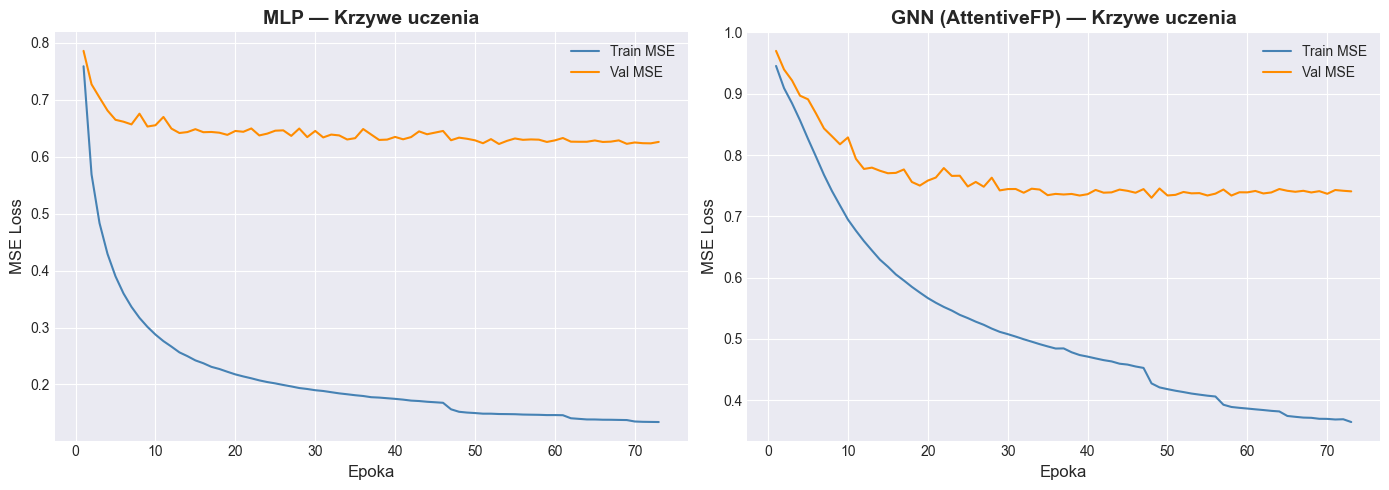

In [19]:
# Krzywe uczenia MLP i GNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MLP
ax = axes[0]
epochs_mlp = range(1, len(mlp_train_losses) + 1)
ax.plot(epochs_mlp, mlp_train_losses, label='Train MSE', color='steelblue')
ax.plot(epochs_mlp, mlp_val_losses,   label='Val MSE',   color='darkorange')
ax.set_xlabel('Epoka', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('MLP — Krzywe uczenia', fontsize=14, fontweight='bold')
ax.legend()

# GNN
ax = axes[1]
epochs_gnn = range(1, len(gnn_train_losses) + 1)
ax.plot(epochs_gnn, gnn_train_losses, label='Train MSE', color='steelblue')
ax.plot(epochs_gnn, gnn_val_losses,   label='Val MSE',   color='darkorange')
ax.set_xlabel('Epoka', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('GNN (AttentiveFP) — Krzywe uczenia', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(MODELS_DIR / "learning_curves.png", dpi=150, bbox_inches='tight')
plt.show()

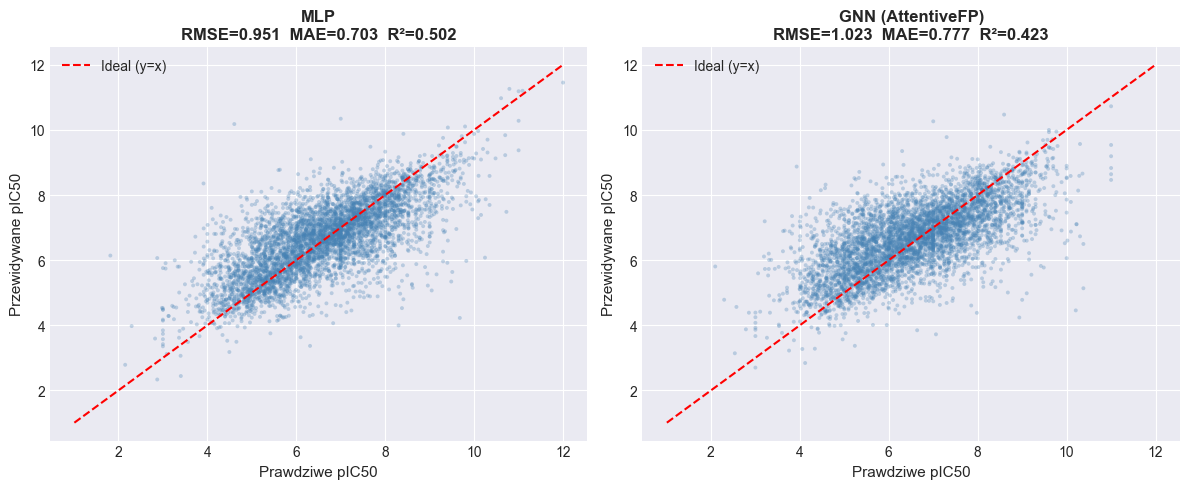

In [20]:
# Predicted vs Actual — MLP i GNN
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_data = [
    ('MLP',              mlp_test_true,  mlp_test_preds, mlp_metrics),
    ('GNN (AttentiveFP)', gnn_test_true,  gnn_test_preds, gnn_metrics),
]

for ax, (title, y_true, y_pred, met) in zip(axes, plot_data):
    n_plot = min(len(y_true), 5000)
    idx    = np.random.choice(len(y_true), n_plot, replace=False)
    ax.scatter(y_true[idx], y_pred[idx], alpha=0.3, s=8, c='steelblue', edgecolors='none')

    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Ideal (y=x)')

    ax.set_xlabel('Prawdziwe pIC50', fontsize=11)
    ax.set_ylabel('Przewidywane pIC50', fontsize=11)
    ax.set_title(
        f'{title}\nRMSE={met["rmse"]:.3f}  MAE={met["mae"]:.3f}  R²={met["r2"]:.3f}',
        fontsize=12, fontweight='bold'
    )
    ax.legend()

plt.tight_layout()
plt.savefig(MODELS_DIR / "predicted_vs_actual.png", dpi=150, bbox_inches='tight')
plt.show()

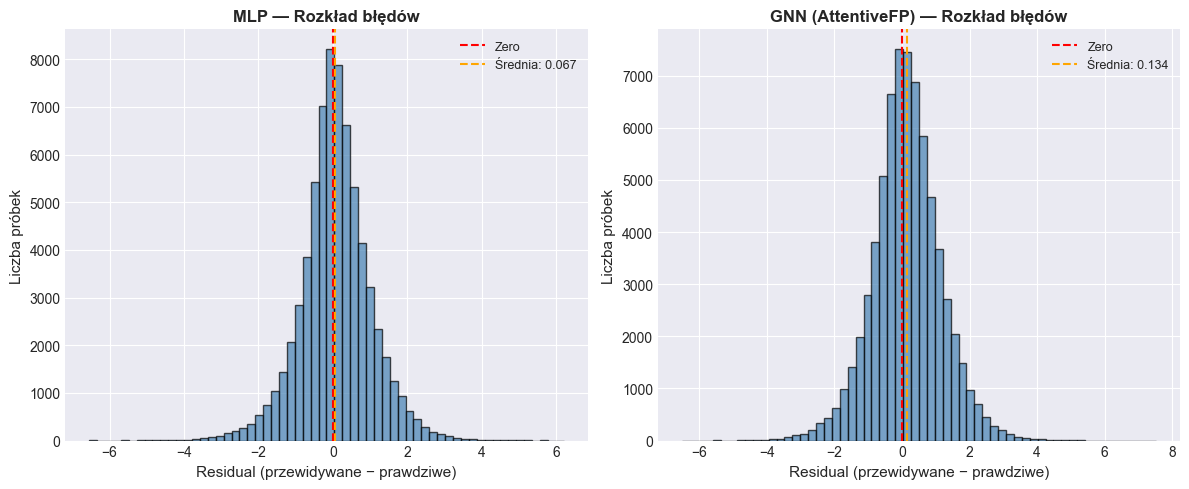

In [21]:
# Rozkład błędów (residuals) — MLP i GNN
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (title, y_true, y_pred, met) in zip(axes, plot_data):
    residuals = y_pred - y_true
    ax.hist(residuals, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
    ax.axvline(residuals.mean(), color='orange', linestyle='--',
               linewidth=1.5, label=f'Średnia: {residuals.mean():.3f}')
    ax.set_xlabel('Residual (przewidywane − prawdziwe)', fontsize=11)
    ax.set_ylabel('Liczba próbek', fontsize=11)
    ax.set_title(f'{title} — Rozkład błędów', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(MODELS_DIR / "residuals.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Zapis Modeli

In [22]:
# Zapis MLP
torch.save({
    'model_state_dict': mlp_model.state_dict(),
    'model_config': {
        'in_dim':      N_FEATURES,
        'hidden_dims': MLP_HIDDEN,
        'dropout':     MLP_DROPOUT,
    },
    'test_metrics': mlp_metrics,
}, MODELS_DIR / "mlp_model.pt")
print(f"MLP zapisany: {MODELS_DIR / 'mlp_model.pt'}")

# Wspólne statystyki per-target
import pickle
with open(MODELS_DIR / "target_stats.pkl", "wb") as f:
    pickle.dump({'tgt_stats': tgt_stats, 'global_mean': global_mean, 'global_std': global_std}, f)
print(f"Statystyki per-target: {MODELS_DIR / 'target_stats.pkl'}")

# Zapis GNN (AttentiveFP)
torch.save({
    'model_state_dict': gnn_model.state_dict(),
    'model_config': {
        'architecture':  'AttentiveFP',
        'node_feat_dim': NODE_FEAT_DIM,
        'edge_feat_dim': EDGE_FEAT_DIM,
        'hidden_dim':    GNN_HIDDEN,
        'n_layers':      GNN_LAYERS,
        'n_timesteps':   GNN_TIMESTEPS,
        'dropout':       GNN_DROPOUT,
        'target_dim':    GNN_TARGET_DIM,
    },
    'normalization': 'per-target (target_stats.pkl)',
    'test_metrics':  gnn_metrics,
}, MODELS_DIR / "gnn_model.pt")
print(f"GNN (AttentiveFP) zapisany: {MODELS_DIR / 'gnn_model.pt'}")

# Zapis per-target modeli
import os
pt_models_dir = MODELS_DIR / "per_target"
pt_models_dir.mkdir(exist_ok=True)
for tgt_id, res in per_target_results.items():
    safe_name = tgt_id.replace('/', '_')
    torch.save({
        'model_state_dict': res.get('model', None),
        'config': {'hidden_dims': PER_TARGET_HIDDEN, 'dropout': PER_TARGET_DROPOUT, 'in_dim': N_FEATURES},
        'test_metrics': res['per_target'],
    }, pt_models_dir / f"mlp_{safe_name}.pt")
if per_target_results:
    print(f"Per-target modele zapisane w: {pt_models_dir}/")

results_summary = {
    model_name: {k: float(v) for k, v in info.items() if k in ('rmse', 'mae', 'r2')}
    for model_name, info in all_results.items()
    if isinstance(info.get('rmse'), (int, float))
}
with open(MODELS_DIR / "results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2)

print(f"\nPodsumowanie wyników: {MODELS_DIR / 'results_summary.json'}")
print(f"\nZawartość {MODELS_DIR}:")
for p in sorted(MODELS_DIR.iterdir()):
    if p.is_file():
        print(f"  {p.name:<35s}  {p.stat().st_size/1024:.1f} KB")


MLP zapisany: C:\Users\LUMA\Documents\Projects\Personal\Chembl\models\mlp_model.pt
Statystyki per-target: C:\Users\LUMA\Documents\Projects\Personal\Chembl\models\target_stats.pkl
GNN (AttentiveFP) zapisany: C:\Users\LUMA\Documents\Projects\Personal\Chembl\models\gnn_model.pt
Per-target modele zapisane w: C:\Users\LUMA\Documents\Projects\Personal\Chembl\models\per_target/

Podsumowanie wyników: C:\Users\LUMA\Documents\Projects\Personal\Chembl\models\results_summary.json

Zawartość C:\Users\LUMA\Documents\Projects\Personal\Chembl\models:
  gnn_model.pt                         9765.9 KB
  learning_curves.png                  99.7 KB
  mlp_model.pt                         44550.5 KB
  predicted_vs_actual.png              302.6 KB
  residuals.png                        72.2 KB
  results_summary.json                 1.2 KB
  target_stats.pkl                     59.9 KB
  xgb_model.json                       10490.7 KB


## 7. Przykład Inferencji: SMILES → pIC50

Tak będzie wyglądało użycie wytrenowanych modeli w praktyce: podajesz SMILES dowolnej cząsteczki, dostajesz przewidywaną wartość pIC50

In [23]:
import pickle
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator

with open(FEATURES_DIR / "mlp_scaler.pkl", "rb") as f:
    inference_scaler = pickle.load(f)
with open(FEATURES_DIR / "mlp_fp_selector.pkl", "rb") as f:
    inference_selector4 = pickle.load(f)   # ECFP4 selector
with open(FEATURES_DIR / "mlp_target_encoder.pkl", "rb") as f:
    inference_tgt_enc, inference_top_targets = pickle.load(f)

try:
    with open(FEATURES_DIR / "mlp_fp6_selector.pkl", "rb") as f:
        inference_selector6 = pickle.load(f)
    _use_ecfp6 = True
    print("ECFP6 selector wczytany — inferencja używa ECFP4 + ECFP6")
except FileNotFoundError:
    inference_selector6 = None
    _use_ecfp6 = False
    print("UWAGA: mlp_fp6_selector.pkl nie znaleziono — używam tylko ECFP4 (uruchom nb03 z ECFP6)")

_TGT_DIM = len(inference_tgt_enc.categories_[0])
print(f"Enkoder targetów: top-{len(inference_top_targets)} + OTHER = {_TGT_DIM} klas")

_morgan4_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
_morgan6_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=2048)


def smiles_to_features(smiles: str, target_chembl_id: str = "OTHER") -> np.ndarray | None:
    """SMILES + opcjonalny target → wektor cech gotowy dla MLP."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hdon = Descriptors.NumHDonors(mol)
    hacc = Descriptors.NumHAcceptors(mol)
    desc = np.array([[
        mw, mol.GetNumAtoms(), Descriptors.HeavyAtomCount(mol),
        Descriptors.NumHeteroatoms(mol), hdon, hacc, logp,
        Descriptors.TPSA(mol), Descriptors.NumAromaticRings(mol),
        Descriptors.NumAliphaticRings(mol), Descriptors.RingCount(mol),
        len([a for a in mol.GetAtoms() if a.GetIsAromatic()]) / mol.GetNumAtoms(),
        Descriptors.NumRotatableBonds(mol), Descriptors.NumSaturatedRings(mol),
        Descriptors.FractionCSP3(mol), Descriptors.MolMR(mol),
        int(mw > 500) + int(logp > 5) + int(hdon > 5) + int(hacc > 10),
    ]], dtype=np.float32)

    desc_scaled = inference_scaler.transform(desc).astype(np.float32)

    fp4 = _morgan4_gen.GetFingerprintAsNumPy(mol).astype(np.float32).reshape(1, -1)
    fp4_sel = inference_selector4.transform(fp4).astype(np.float32)

    if _use_ecfp6:
        fp6     = _morgan6_gen.GetFingerprintAsNumPy(mol).astype(np.float32).reshape(1, -1)
        fp6_sel = inference_selector6.transform(fp6).astype(np.float32)
        fp_part = np.concatenate([fp4_sel, fp6_sel], axis=1)
    else:
        fp_part = fp4_sel

    tgt_label   = target_chembl_id if target_chembl_id in inference_top_targets else "OTHER"
    tgt_enc_vec = inference_tgt_enc.transform([[tgt_label]]).astype(np.float32)

    return np.concatenate([desc_scaled, fp_part, tgt_enc_vec], axis=1)


@torch.no_grad()
def predict_mlp(smiles: str, target_chembl_id: str = "OTHER") -> float | None:
    """Przewiduje pIC50 dla podanego SMILES (globalny MLP)."""
    feats = smiles_to_features(smiles, target_chembl_id)
    if feats is None:
        return None
    mlp_model.eval()
    x = torch.FloatTensor(feats).to(DEVICE)
    pred_norm = mlp_model(x).item()
    mean, std = tgt_stats.get(target_chembl_id, (global_mean, global_std))
    return pred_norm * std + mean


# Przykłady
examples = [
    ("Ibrutynib (BTK)",    "CC(C#C)n1cc(c2ncnc3[nH]ccc23)cc1-c1cccc(NC(=O)/C=C/CN(C)C)c1", "CHEMBL5251"),
    ("Erlotynib (EGFR)",   "C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1",                    "CHEMBL203"),
    ("Ruxolitynib (JAK1)", "C=CC(=O)Nc1ccn(C2CCCC2)n1",                                     "CHEMBL2835"),
    ("Aspiryna (brak)",    "CC(=O)Oc1ccccc1C(=O)O",                                          "OTHER"),
]

print(f"\n{'Cząsteczka':25s}  {'MLP pIC50':>10}  {'IC50 nM':>12}")
print("-" * 52)
for name, smi, tgt in examples:
    p = predict_mlp(smi, tgt)
    if p is not None:
        ic50_nm = 10 ** (-p + 9)
        print(f"{name:25s}  {p:>10.3f}  {ic50_nm:>10.1f} nM")
    else:
        print(f"{name:25s}  Niepoprawny SMILES")


ECFP6 selector wczytany — inferencja używa ECFP4 + ECFP6
Enkoder targetów: top-100 + OTHER = 101 klas

Cząsteczka                  MLP pIC50       IC50 nM
----------------------------------------------------
Ibrutynib (BTK)                 8.690         2.0 nM
Erlotynib (EGFR)                7.508        31.0 nM
Ruxolitynib (JAK1)              5.918      1207.5 nM
Aspiryna (brak)                 4.573     26746.2 nM


## Podsumowanie

### Wytrenowane modele:
- `models/mlp_model.pt` — MLP
- `models/gnn_model.pt` — GNN
- `models/results_summary.json` — porównanie metryk
- `models/learning_curves.png`, `predicted_vs_actual.png`, `residuals.png` — wykresy